## Knowledge Graph Pipeline: PEPs & Offshore Networks

In [1]:
import re, unicodedata, time, warnings
from pathlib import Path
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from rapidfuzz import process as rfprocess, fuzz
from tqdm.auto import tqdm
from joblib import Parallel, delayed

warnings.filterwarnings("ignore")

/Users/divyanshpurohit/Desktop/Acad/Q4/Knowledge Engineering/Assignments/group-project/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# path for data directory
DATA = Path('data')
ICIJ_DIR = DATA / 'icij'
WIKI_DIR = DATA / 'wikidata'
OS_DIR = Path('data_opensanctions')

OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

N_JOBS = 10

FUZZY_NAME_THRESHOLD = 80   # min rapidfuzz token_set_ratio
COMBINED_THRESHOLD   = 52   # min combined score for keep match
HIGH_CONF_THRESHOLD  = 72   # combined score for is_pep=True

# Jurisdiction codes
TAX_HAVEN_CODES = {
    'VGB','CYM','PAN','BMU','BHS','LUX','MLT','LIE','IMN','GGY','JEY',
    'SAM','WSM','MSR','MHL','NIU','COK','VUT','SGP','HKG','CYP','MCO',
    'GIB','TCA','ATG','GRD','KNA','VCT','DMA','BRB','ABW','SYC','MUS',
    'ARE','LBR','ANT','NRU','PLW',
}

## 2 Dataset Composition
### ICIJ Offshore Leaks

In [3]:
def parse_country(s):
    if not isinstance(s, str) or not s.strip():
        return set()
    return {c.strip().lower() for c in s.split(";") if c.strip()}

def parse_code(s):
    if not isinstance(s, str) or not s.strip():
        return set()
    return {c.strip().upper() for c in s.split(";") if c.strip()}

def load_icij_node():
    csv_files = [
        ("nodes-entities.csv",       "entity"),
        ("nodes-officers.csv",       "officer"),
        ("nodes-intermediaries.csv", "intermediary"),
        ("nodes-addresses.csv",      "address"),
        ("nodes-others.csv",         "other"),
    ]
    frames = []
    for fname, ntype in csv_files:
        
        path = ICIJ_DIR / fname
        
        keep = ["node_id","name","countries","country_codes","sourceID",
                "address","company_type","jurisdiction","incorporation_date"]
        
        avail = pd.read_csv(path, nrows=0).columns.tolist()
        
        df = pd.read_csv(path, low_memory=False, usecols=[c for c in keep if c in avail])
        df["node_type"] = ntype
        
        frames.append(df)
        
        print(f'{fname:<35}{len(df):>8,} rows')
    
    out = pd.concat(frames, ignore_index=True)
    out["node_id"] = out["node_id"].astype(str)
    
    # convert country field into set
    out["country_set"] = out["countries"].apply(parse_country)
    out["code_set"]    = out["country_codes"].apply(parse_code)
    
    # for setting tax haven flag
    out["is_tax_haven"] = out["code_set"].apply(lambda c: bool(c & TAX_HAVEN_CODES))
    
    if "jurisdiction" in out.columns:
        out["is_tax_haven"] |= out["jurisdiction"].apply(
            lambda j: isinstance(j, str) and j.strip().upper() in TAX_HAVEN_CODES
        )
    return out

print("ICIJ node files")
nodes = load_icij_node()
print(f'Total ICIJ nodes : {len(nodes):,}')
th = nodes[(nodes.is_tax_haven) & (nodes.node_type == "entity")].shape[0]
print(f'Entity nodes (tax-havea jurisdictions : {th}')
nodes[["node_id","name","node_type","countries","is_tax_haven"]].head(4)

ICIJ node files
nodes-entities.csv                  814,344 rows
nodes-officers.csv                  771,315 rows
nodes-intermediaries.csv             25,629 rows
nodes-addresses.csv                 402,246 rows
nodes-others.csv                      2,989 rows
Total ICIJ nodes : 2,016,523
Entity nodes (tax-havea jurisdictions : 473514


,node_id,name,node_type,countries,is_tax_haven
0,10000001,"TIANSHENG INDUSTRY AND TRADING CO., LTD.",entity,Hong Kong,True
1,10000002,"NINGBO SUNRISE ENTERPRISES UNITED CO., LTD.",entity,Hong Kong,True
2,10000003,"HOTFOCUS CO., LTD.",entity,Hong Kong,True
3,10000004,"SKY-BLUE GIFTS & TOYS CO., LTD.",entity,Hong Kong,True


In [4]:
print("ICIJ relationships")
rels = pd.read_csv(ICIJ_DIR / "relationships.csv", low_memory=False)
rels["node_id_start"] = rels["node_id_start"].astype(str)
rels["node_id_end"]   = rels["node_id_end"].astype(str)
print(f'Total edges: {len(rels)}')
print(rels["rel_type"].value_counts().to_string())

ICIJ relationships
Total edges: 3339267
rel_type
officer_of                  1720357
registered_address           832721
intermediary_of              598546
same_name_as                 104170
similar                       46761
same_company_as               15523
connected_to                  12145
same_as                        4272
same_id_as                     3120
underlying                     1308
similar_company_as              203
probably_same_officer_as        132
same_address_as                   5
same_intermediary_as              4


In [5]:
print("ICIJ Node Summary")
for ntype, grp in nodes.groupby("node_type"):
    miss_name = grp["name"].isna().sum()
    miss_ctry = grp["countries"].isna().sum()
    print(f'  {ntype} {len(grp)} || '
          f'missing name: {miss_name}'
          f'missing country: {miss_ctry}')

print(f'ICIJ leak source distribution:')
print(nodes["sourceID"].value_counts().to_string())

ICIJ Node Summary
  address 402246 || missing name: 178889missing country: 125137
  entity 814344 || missing name: 29missing country: 309353
  intermediary 25629 || missing name: 1missing country: 3616
  officer 771315 || missing name: 63missing country: 302334
  other 2989 || missing name: 0missing country: 2603
ICIJ leak source distribution:
sourceID
Panama Papers                                                559600
Paradise Papers - Malta corporate registry                   314375
Offshore Leaks                                               278693
Bahamas Leaks                                                202242
Paradise Papers - Barbados corporate registry                190492
Paradise Papers - Appleby                                    163267
Paradise Papers - Aruba corporate registry                    99196
Paradise Papers - Nevis corporate registry                    70986
Pandora Papers - Alemán, Cordero, Galindo & Lee (Alcogal)     54100
Paradise Papers - Bahamas corpora

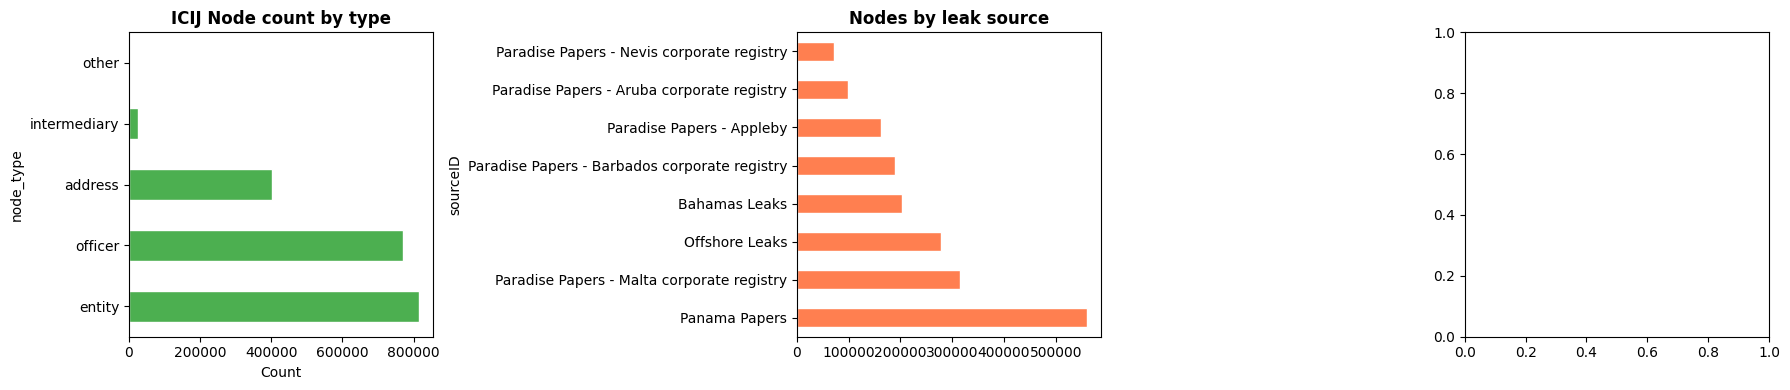

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Node type distribution
tc = nodes["node_type"].value_counts()
tc.plot(kind="barh", ax=axes[0], color="#4CAF50", edgecolor="white")
axes[0].set_title("ICIJ Node count by type", fontweight="bold")
axes[0].set_xlabel("Count")

# Leak source distribution
sc = nodes["sourceID"].value_counts().head(8)
sc.plot(kind="barh", ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Nodes by leak source", fontweight="bold")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_icij_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

### Wikidata — Politicians and Government Officials

In [7]:
persons_raw       = pd.read_csv(WIKI_DIR / 'persons.csv')
associates_raw    = pd.read_csv(WIKI_DIR / 'associates.csv')
family_raw        = pd.read_csv(WIKI_DIR / 'family.csv')
family_named_raw  = pd.read_csv(WIKI_DIR / 'family_named.csv')
positions_raw     = pd.read_csv(WIKI_DIR / 'positions.csv')
occupancy_raw     = pd.read_csv(WIKI_DIR / 'occupancy.csv')
ownership_raw     = pd.read_csv(WIKI_DIR / 'ownership.csv')

pep_flattened_raw = pd.read_csv(WIKI_DIR / 'pep_flattened.csv')

print(f'  persons      : {len(persons_raw)}')
print(f'  pep_flattened: {len(pep_flattened_raw)}  (rows = one per position per PEP)')
print(f'  associates   : {len(associates_raw)}')
print(f'  family       : {len(family_raw)}')
print(f'  positions    : {len(positions_raw)}')
print(f'  occupancy    : {len(occupancy_raw)}')
print(f'  ownership    : {len(ownership_raw)}')


  persons      : 752304
  pep_flattened: 894097  (rows = one per position per PEP)
  associates   : 2010
  family       : 44498
  positions    : 174146
  occupancy    : 895251
  ownership    : 705


In [8]:
def fix_mojibake(s):
    try:
        return s.encode('latin-1').decode('utf-8')
    except Exception:
        return s

pols = persons_raw.copy()

is_qid = pols['name'].str.match(r'^Q\d+$', na=True)
print(f'QID-only rows dropped : {is_qid.sum():,}')
pols = pols[~is_qid].copy()

pols['name'] = pols['name'].apply(fix_mojibake)

pols['qid'] = pols['wikidata_id'].where(pols['wikidata_id'].notna(), pols['person_id'])

# 4. (for position_name display only)
occ_pos = occupancy_raw.merge(
    positions_raw[['position_id','position_name','country']],
    on='position_id', how='left'
)
most_recent_pos = (
    occ_pos
    .assign(_date=pd.to_datetime(occ_pos['start_date'], errors='coerce'))
    .sort_values('_date', ascending=False, na_position='last')
    .groupby('person_id').first().reset_index()
    [['person_id','position_name','country']]
)
pols = pols.merge(most_recent_pos, on='person_id', how='left')

# 5. Deduplicate
pols_dedup = pols.drop_duplicates(subset='person_id', keep='first').reset_index(drop=True)

# 6. ISO 2-letter country sets for joining
def _parse_iso2_set(s):
    if pd.isna(s) or not str(s).strip() or str(s).lower() == 'nan':
        return set()
    return {c.strip().lower() for c in str(s).split(';') if c.strip()}

# citizenship from persons.csv (ISO 2-letter, e.g. 'kr', 'gb')
pols_dedup['citizenship_iso2'] = pols_dedup['citizenship'].apply(_parse_iso2_set)

# aggregate ALL position countries from pep_flattened.csv
# pep_flattened has one row per (person, position); country is ISO 2-letter.
all_pos_iso2 = (
    pep_flattened_raw
    .groupby('person_id')['country']
    .apply(lambda x: {c.strip().lower() for c in x.dropna() if str(c).strip()})
    .reset_index()
    .rename(columns={'country': 'all_pos_iso2'})
)
pols_dedup = pols_dedup.merge(all_pos_iso2, on='person_id', how='left')
pols_dedup['all_pos_iso2'] = pols_dedup['all_pos_iso2'].apply(
    lambda x: x if isinstance(x, set) else set()
)

pols_dedup['all_iso2'] = pols_dedup.apply(
    lambda r: r['citizenship_iso2'] | r['all_pos_iso2'], axis=1
)

print(f'Named unique persons: {len(pols_dedup)}')
print(f'is_pep=True:{int(pols_dedup["is_pep"].sum())}')
print(f'with citizenship_iso2: {pols_dedup["citizenship_iso2"].apply(bool).sum()}')
print(f'with all_pos_iso2 : {pols_dedup["all_pos_iso2"].apply(bool).sum()}')
print(f'with any country: {pols_dedup["all_iso2"].apply(bool).sum()}')
pols_dedup[['person_id','name','position_name','citizenship','country','is_pep']].head(5)


QID-only rows dropped : 1,070
Named unique persons: 751234
is_pep=True:695324
with citizenship_iso2: 472220
with all_pos_iso2 : 637592
with any country: 692789


,person_id,name,position_name,citizenship,country,is_pep
0,NK-24KdLmG7SRFdS5GgJbgLSs,"AW Kim Geok, PBS, PPA(P)",Director/School of Electronics & Info-Comm Tec...,NaN,sg,True
1,NK-24W9aosPLEsueQ5grGVNiK,Christophane FOO,"Chief Human Capital Officer / Human Capital, E...",NaN,sg,True
2,NK-24umfCYjCezXnS2gcCfT8F,Andreas Norvik,"Styremedlem, NRK NORMANNSLØKKA AS",NaN,no,True
3,NK-25bxtBgjBTs6asnevNVgsE,Sambhaji Rao Shinde,NaN,NaN,NaN,False
4,NK-2AaUhJdZeBxnxVKVF7fTVv,Marica Montemaggi,Member of the Grand and General Council,sm,sm,True


## 4 Data Transformation and Presentation

### Entity Matching

In [9]:
import re

different_titles = re.compile(
    r'\b(mr|mrs|ms|dr|prof|sir|dame|hon|the|rt|rev|lord|lady|sen|rep|gen|col|maj|cdr|adm)\b',
    re.IGNORECASE
)

def normalise(name):
    if not isinstance(name, str) or not name.strip():
        return ''
    name = unicodedata.normalize('NFD', name)
    name = ''.join(c for c in name if unicodedata.category(c) != 'Mn')
    name = name.lower()
    name = different_titles.sub('', name)
    name = re.sub(r'[^a-z0-9 ]', ' ', name)
    return re.sub(r'\s+', ' ', name).strip()


ISO3_TO_ISO2 = {
    'AFG':'af','ALA':'ax','ALB':'al','DZA':'dz','ASM':'as','AND':'ad','AGO':'ao',
    'AIA':'ai','ATA':'aq','ATG':'ag','ARG':'ar','ARM':'am','ABW':'aw','AUS':'au',
    'AUT':'at','AZE':'az','BHS':'bs','BHR':'bh','BGD':'bd','BRB':'bb','BLR':'by',
    'BEL':'be','BLZ':'bz','BEN':'bj','BMU':'bm','BTN':'bt','BOL':'bo','BES':'bq',
    'BIH':'ba','BWA':'bw','BVT':'bv','BRA':'br','IOT':'io','BRN':'bn','BGR':'bg',
    'BFA':'bf','BDI':'bi','CPV':'cv','KHM':'kh','CMR':'cm','CAN':'ca','CYM':'ky',
    'CAF':'cf','TCD':'td','CHL':'cl','CHN':'cn','CXR':'cx','CCK':'cc','COL':'co',
    'COM':'km','COD':'cd','COG':'cg','COK':'ck','CRI':'cr','CIV':'ci','HRV':'hr',
    'CUB':'cu','CUW':'cw','CYP':'cy','CZE':'cz','DNK':'dk','DJI':'dj','DMA':'dm',
    'DOM':'do','ECU':'ec','EGY':'eg','SLV':'sv','GNQ':'gq','ERI':'er','EST':'ee',
    'SWZ':'sz','ETH':'et','FLK':'fk','FRO':'fo','FJI':'fj','FIN':'fi','FRA':'fr',
    'GUF':'gf','PYF':'pf','ATF':'tf','GAB':'ga','GMB':'gm','GEO':'ge','DEU':'de',
    'GHA':'gh','GIB':'gi','GRC':'gr','GRL':'gl','GRD':'gd','GLP':'gp','GUM':'gu',
    'GTM':'gt','GGY':'gg','GIN':'gn','GNB':'gw','GUY':'gy','HTI':'ht','HMD':'hm',
    'VAT':'va','HND':'hn','HKG':'hk','HUN':'hu','ISL':'is','IND':'in','IDN':'id',
    'IRN':'ir','IRQ':'iq','IRL':'ie','IMN':'im','ISR':'il','ITA':'it','JAM':'jm',
    'JPN':'jp','JEY':'je','JOR':'jo','KAZ':'kz','KEN':'ke','KIR':'ki','PRK':'kp',
    'KOR':'kr','KWT':'kw','KGZ':'kg','LAO':'la','LVA':'lv','LBN':'lb','LSO':'ls',
    'LBR':'lr','LBY':'ly','LIE':'li','LTU':'lt','LUX':'lu','MAC':'mo','MDG':'mg',
    'MWI':'mw','MYS':'my','MDV':'mv','MLI':'ml','MLT':'mt','MHL':'mh','MTQ':'mq',
    'MRT':'mr','MUS':'mu','MYT':'yt','MEX':'mx','FSM':'fm','MDA':'md','MCO':'mc',
    'MNG':'mn','MNE':'me','MSR':'ms','MAR':'ma','MOZ':'mz','MMR':'mm','NAM':'na',
    'NRU':'nr','NPL':'np','NLD':'nl','NCL':'nc','NZL':'nz','NIC':'ni','NER':'ne',
    'NGA':'ng','NIU':'nu','NFK':'nf','MKD':'mk','MNP':'mp','NOR':'no','OMN':'om',
    'PAK':'pk','PLW':'pw','PSE':'ps','PAN':'pa','PNG':'pg','PRY':'py','PER':'pe',
    'PHL':'ph','PCN':'pn','POL':'pl','PRT':'pt','PRI':'pr','QAT':'qa','REU':'re',
    'ROU':'ro','RUS':'ru','RWA':'rw','BLM':'bl','SHN':'sh','KNA':'kn','LCA':'lc',
    'MAF':'mf','SPM':'pm','VCT':'vc','WSM':'ws','SMR':'sm','STP':'st','SAU':'sa',
    'SEN':'sn','SRB':'rs','SYC':'sc','SLE':'sl','SGP':'sg','SXM':'sx','SVK':'sk',
    'SVN':'si','SLB':'sb','SOM':'so','ZAF':'za','SGS':'gs','SSD':'ss','ESP':'es',
    'LKA':'lk','SDN':'sd','SUR':'sr','SJM':'sj','SWE':'se','CHE':'ch','SYR':'sy',
    'TWN':'tw','TJK':'tj','TZA':'tz','THA':'th','TLS':'tl','TGO':'tg','TKL':'tk',
    'TON':'to','TTO':'tt','TUN':'tn','TUR':'tr','TKM':'tm','TCA':'tc','TUV':'tv',
    'UGA':'ug','UKR':'ua','ARE':'ae','GBR':'gb','USA':'us','UMI':'um','URY':'uy',
    'UZB':'uz','VUT':'vu','VEN':'ve','VNM':'vn','VGB':'vg','VIR':'vi','WLF':'wf',
    'ESH':'eh','YEM':'ye','ZMB':'zm','ZWE':'zw','XKX':'xk','ANT':'an','SCG':'cs',
}

def parse_icij_codes(s):
    if pd.isna(s) or not str(s).strip():
        return set()
    return {ISO3_TO_ISO2.get(c.strip().upper(), c.strip().lower()[:2])
            for c in str(s).split(';') if c.strip()}

def combined_score_v3(name_score, icij_iso2, wiki_iso2):
    if wiki_iso2 and icij_iso2:
        cc = 100.0 if (wiki_iso2 & icij_iso2) else 0.0
    elif not wiki_iso2 and not icij_iso2:
        cc = 55.0  
    elif not wiki_iso2:
        cc = 55.0  
    else:
        cc = 35.0
    return round(0.55 * name_score + 0.45 * cc, 2), cc

def confidence_tier_v3(name_score, country_component, combined):
    if name_score >= 99.0 and country_component > 0.0:
        return 'high'
    if combined >= HIGH_CONF_THRESHOLD: return 'high'
    if combined >= COMBINED_THRESHOLD:  return 'medium'
    return 'low'

officers = nodes[nodes['node_type'] == 'officer'].copy()
print(f'Officer nodes: {len(officers):,}')
officers['name_norm']    = officers['name'].apply(normalise)
officers['country_iso2'] = officers['country_codes'].apply(parse_icij_codes)
pols_dedup['name_norm']  = pols_dedup['name'].apply(normalise)

officer_norm_index = defaultdict(list)
for row in officers[['node_id','name_norm','country_iso2']].itertuples(index=False):
    if row.name_norm:
        officer_norm_index[row.name_norm].append((row.node_id, row.country_iso2))
officer_norm_keys = list(officer_norm_index.keys())
print(f'Unique normalised officer names: {len(officer_norm_keys)}')

#testing if this works
for orig in ['Eduardo Alvarez Tunon', 'Mr. William Mackie III', 'BRUCE W. LEANDER']:
    print(f'  {orig!r}  =>  {normalise(orig)}')


Officer nodes: 771,315
Unique normalised officer names: 505874
  'Eduardo Alvarez Tunon'  =>  eduardo alvarez tunon
  'Mr. William Mackie III'  =>  william mackie iii
  'BRUCE W. LEANDER'  =>  bruce w leander


In [10]:
cache_file = OUTPUT_DIR / 'pep_matches_v3.csv'

if cache_file.exists():
    matches_df  = pd.read_csv(cache_file, low_memory=False)
    from_cache = True
    has_conf = 'confidence' in matches_df.columns
    print(f'  Rows     : {len(matches_df)}')
    if has_conf:
        for tier in ['high','medium','low']:
            print(f'  {tier:<8}: {(matches_df.confidence==tier).sum():,}')
        pep_node_ids = {str(x) for x in matches_df[matches_df.confidence=='high']['officer_node_id'].dropna()}
    else:
        pep_node_ids = {str(x) for x in matches_df['officer_node_id'].dropna()}
    print(f'PEP officernodes (high-conf): {len(pep_node_ids)}')
else:
    from_cache = False
    token_to_keys = defaultdict(set)
    for key in officer_norm_keys:
        for tok in key.split():
            if len(tok) >= 3:
                token_to_keys[tok].add(key)

    def match_politician(pol, token_idx, full_idx, name_thr, comb_thr):
        pname     = pol['name_norm']
        wiki_iso2 = pol.get('all_iso2', set()) or set()
        qid       = pol['qid']
        pol_name  = pol['name']
        if not pname:
            return []

            
        if pname in full_idx:
            res = []
            for nid, icij_iso2 in full_idx[pname]:
                cs, cc = combined_score_v3(100.0, icij_iso2, wiki_iso2)
                conf = confidence_tier_v3(100.0, cc, cs)
                res.append((qid, pol_name, nid, pname, 100.0, 'exact', cs, conf))
            return res

            
        tokens = [t for t in pname.split() if len(t) >= 3]
        if not tokens:
            
            return []

            
        candidates = set()
        
        for t in tokens:
            candidates |= token_idx.get(t, set())
            
        if not candidates:
            return []
            
        hits = rfprocess.extract(
            pname, list(candidates),
            scorer=fuzz.token_set_ratio,
            score_cutoff=name_thr,
            limit=5
        )
        
        res = []
        for best_key, name_score, _ in hits:
            for nid, icij_iso2 in full_idx[best_key]:
                cs, cc = combined_score_v3(float(name_score), icij_iso2, wiki_iso2)
                if cs >= comb_thr:
                    conf = confidence_tier_v3(float(name_score), cc, cs)
                    res.append((qid, pol_name, nid, best_key, name_score, 'fuzzy', cs, conf))
        return res

    pols_to_match = pols_dedup[pols_dedup['is_pep'] == True].copy()
    pol_records   = pols_to_match[['qid','name','name_norm','all_iso2']].to_dict('records')
    print(f'Matching {len(pol_records):,} PEPs against {len(officer_norm_keys):,} officer names')
    print(f'Name threshold: {FUZZY_NAME_THRESHOLD}  |  Combined threshold: {COMBINED_THRESHOLD}')

  
    raw = Parallel(n_jobs=N_JOBS, backend='threading', verbose=0)(
        delayed(match_politician)(p, token_to_keys, officer_norm_index,
                                    FUZZY_NAME_THRESHOLD, COMBINED_THRESHOLD)
        for p in tqdm(pol_records, desc='Matching PEPs v3')
    )
    flat = [m for sub in raw for m in sub]
    matches_df = pd.DataFrame(flat, columns=[
        'qid','politician_name','officer_node_id','officer_name_norm',
        'name_score','method','combined_score','confidence'
    ])
   
    for tier in ['high','medium','low']:
        print(f'  {tier:<8}: {(matches_df.confidence==tier).sum():,}')
    pep_node_ids = {str(x) for x in matches_df[matches_df.confidence=='high']['officer_node_id'].dropna()}
    
    matches_df.to_csv(cache_file, index=False)


Matching 695,324 PEPs against 505,874 officer names
Name threshold: 80  |  Combined threshold: 52


Matching PEPs v3: 100%|█████████████████████████████████████████████████████████████████████████████| 695324/695324 [12:06<00:00, 957.53it/s]


  high    : 255,458
  medium  : 471,046
  low     : 0


In [11]:
OS_DIR = Path('data_opensanctions')

sanctions_raw = pd.read_csv(OS_DIR/'consolidated sanctions'/'targets.simple.csv')
warrants_raw  = pd.read_csv(OS_DIR / 'warrants and criminal entities' / 'targets.simple.csv')

print(f'Consolidated sanctions:{len(sanctions_raw)} entities')
print(f'Warrants & criminal:{len(warrants_raw)} entities')

def expand_names(row):
    names = [str(row['name'])] if pd.notna(row['name']) else []
    if pd.notna(row['aliases']):
        names += [a.strip() for a in str(row['aliases']).split(';') if a.strip()]
    return names

def parse_iso2(s):
    if pd.isna(s) or not str(s).strip(): return set()
    return {c.strip().lower() for c in str(s).split(';') if c.strip()}

# Sanctioned persons 
sanctions_persons = sanctions_raw[sanctions_raw['schema'] == 'Person'].copy()
sanctions_persons['all_names']    = sanctions_persons.apply(expand_names, axis=1)
sanctions_persons['name_norms']   = sanctions_persons['all_names'].apply(
    lambda ns: list({normalise(n) for n in ns if normalise(n)})
)
sanctions_persons['country_iso2'] = sanctions_persons['countries'].apply(parse_iso2)
sanctions_persons['program']      = sanctions_persons['program_ids'].fillna('').astype(str)

# Sanctioned organisations matched with ICIJ entities
sanctions_orgs = sanctions_raw[sanctions_raw['schema'].isin(['Organization','Company','LegalEntity'])].copy()
sanctions_orgs['all_names']  = sanctions_orgs.apply(expand_names, axis=1)
sanctions_orgs['name_norms'] = sanctions_orgs['all_names'].apply(
    lambda ns: list({normalise(n) for n in ns if normalise(n)})
)

# Warrant persons
warrants_persons = warrants_raw[warrants_raw['schema'] == 'Person'].copy()
warrants_persons['all_names']    = warrants_persons.apply(expand_names, axis=1)
warrants_persons['name_norms']   = warrants_persons['all_names'].apply(
    lambda ns: list({normalise(n) for n in ns if normalise(n)})
)
warrants_persons['country_iso2'] = warrants_persons['countries'].apply(parse_iso2)
warrants_persons['dataset_label'] = warrants_persons['dataset'].fillna('').astype(str)

print(f'\n Sanctioned persons {len(sanctions_persons)}')
print(f'Sanctioned orgs/companies {len(sanctions_orgs)}')
print(f'Warrant persons  {len(warrants_persons)}')


Consolidated sanctions:70673 entities
Warrants & criminal:248413 entities

 Sanctioned persons 39446
Sanctioned orgs/companies 24213
Warrant persons  170595


In [12]:
# organisation matching
entities_df = nodes[nodes['node_type'] == 'entity'].copy()
entities_df['name_norm'] = entities_df['name'].apply(normalise)

entity_norm_index = defaultdict(list)

for _row in entities_df[['node_id','name_norm']].itertuples(index=False):
    if _row.name_norm:
        entity_norm_index[_row.name_norm].append(_row.node_id)
        
print(f'{len(entity_norm_index)} unique names')

def match_person_to_officers(persons_df, label):
    matched = {}
    for _, row in persons_df.iterrows():
        person_iso2 = row['country_iso2']

        program     = row.get('program', row.get('dataset_label', ''))
        for name_norm in row['name_norms']:
            
            if name_norm in officer_norm_index:
                for nid, icij_iso2 in officer_norm_index[name_norm]:

                    
                    if not person_iso2 or not icij_iso2 or (person_iso2 & icij_iso2):
                        
                        if nid not in matched:
                            matched[nid] = str(program)
    print(f'{label}: {len(matched)} ICIJ officer nodes matched')
    return matched

def match_orgs_to_entities(orgs_df, label):
    matched = set()
    for _, row in orgs_df.iterrows():
        for name_norm in row['name_norms']:
            for nid in entity_norm_index.get(name_norm, []):
                matched.add(nid)
    print(f'  {label}: {len(matched):,} ICIJ entity nodes matched')
    return matched

print('Matching')
sanctioned_officer_ids = match_person_to_officers(
    sanctions_persons, 'Consolidated sanctions (persons)')
wanted_officer_ids     = match_person_to_officers(
    warrants_persons, 'Warrants & criminal (persons)')
sanctioned_entity_ids  = match_orgs_to_entities(
    sanctions_orgs, 'Sanctioned orgs/companies')

sanctioned_officer_set = set(sanctioned_officer_ids)
wanted_officer_set     = set(wanted_officer_ids)

pep_and_sanctioned = pep_node_ids & sanctioned_officer_set
pep_and_wanted     = pep_node_ids & wanted_officer_set
print(f'\nDual-risk nodes (PEP + sanctioned):{len(pep_and_sanctioned)}')
print(f'Dual-risk nodes (PEP + wanted): {len(pep_and_wanted)}')


772313 unique names
Matching
Consolidated sanctions (persons): 942 ICIJ officer nodes matched
Warrants & criminal (persons): 1234 ICIJ officer nodes matched
  Sanctioned orgs/companies: 213 ICIJ entity nodes matched

Dual-risk nodes (PEP + sanctioned):579
Dual-risk nodes (PEP + wanted): 512


In [13]:
if not from_cache:
    matches_df = matches_df.merge(
        pols_dedup[['qid','position_name','country']], on='qid', how='left'
    )

    matches_df = matches_df.merge(
        officers[['node_id','name','countries','sourceID']].rename(
            columns={'node_id':'officer_node_id','name':'officer_icij_name'}),
        on='officer_node_id', how='left'
    )
    matches_df.to_csv(OUTPUT_DIR / 'pep_matches.csv', index=False)
    print(f'saved {OUTPUT_DIR / "pep_matches.csv"}')

if 'confidence' in matches_df.columns:
    pep_node_ids = {str(x) for x in matches_df[matches_df.confidence=='high']['officer_node_id'].dropna()}
else:
    pep_node_ids = {str(x) for x in matches_df['officer_node_id'].dropna()}

print('\nSample high-confidence matches:')
cols = ['politician_name','officer_icij_name','name_score','combined_score','confidence','position_name','country','sourceID']
avail = [c for c in cols if c in matches_df.columns]
hc = matches_df[matches_df['confidence']=='high'] if 'confidence' in matches_df.columns else matches_df
print(hc[avail].head(5).to_string(index=False))

if 'confidence' in matches_df.columns:
    lc = matches_df[matches_df['confidence']=='low']
    
    if len(lc):
        print(lc[avail].head(5).to_string(index=False))

saved output/pep_matches.csv

Sample high-confidence matches:
    politician_name                       officer_icij_name  name_score  combined_score confidence                                                          position_name country                                                  sourceID
    Tord Fredriksen                        ASTRI FREDRIKSEN   83.870968           91.13       high                                            Varamedlem, SPACE NORWAY AS      no                                             Panama Papers
    Tord Fredriksen               ARNE OLAV AURE FREDRIKSEN   80.000000           89.00       high                                            Varamedlem, SPACE NORWAY AS      no                Paradise Papers - Malta corporate registry
    JORGE FERNANDEZ JORGE DANIEL FERNANDEZ GEORGE R. AMADOR  100.000000           70.75       high                            member of the Argentine Chamber of Deputies      ar             Paradise Papers - Barbados corporate reg

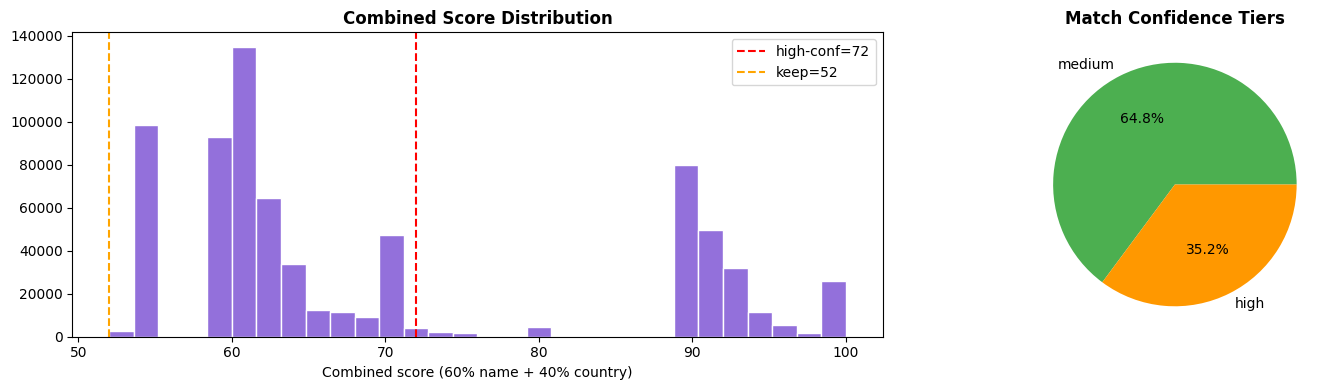

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Combined score distribution
if 'combined_score' in matches_df.columns:
    axes[0].hist(matches_df['combined_score'], bins=30, color='mediumpurple', edgecolor='white')
    axes[0].axvline(HIGH_CONF_THRESHOLD, color='red', ls='--', label=f'high-conf={HIGH_CONF_THRESHOLD}')
    axes[0].axvline(COMBINED_THRESHOLD,  color='orange', ls='--', label=f'keep={COMBINED_THRESHOLD}')
    axes[0].set_title('Combined Score Distribution', fontweight='bold')
    axes[0].set_xlabel('Combined score (60% name + 40% country)')
    axes[0].legend()

# breakdown of confidence  tiers
if 'confidence' in matches_df.columns:
    tc = matches_df['confidence'].value_counts()
    axes[1].pie(tc, labels=tc.index, autopct='%1.1f%%', colors=['#4CAF50','#FF9800','#F44336'])
    axes[1].set_title('Match Confidence Tiers', fontweight='bold')

plt.tight_layout()
plt.show()

### 5 Knowledge Graph Construction

In [15]:
# Build per-node pep score lookup (max combined_score per officer node)
pep_score_map = {}
pep_conf_map  = {}

if 'combined_score' in matches_df.columns:
    for row in matches_df.itertuples(index=False):
        nid = str(row.officer_node_id)
        sc  = float(row.combined_score) if pd.notna(row.combined_score) else 0.0
        if nid not in pep_score_map or sc > pep_score_map[nid]:
            pep_score_map[nid] = sc
            pep_conf_map[nid]  = str(row.confidence) if hasattr(row, 'confidence') else ''

print('Building knowledge graph ')


G_directed = nx.DiGraph()
G_directed.add_nodes_from(nodes['node_id'].values)

_pep_ids_str = {str(x) for x in pep_node_ids}

nx.set_node_attributes(G_directed, dict(zip(nodes['node_id'], nodes['name'].fillna(''))),'name')
nx.set_node_attributes(G_directed, dict(zip(nodes['node_id'], nodes['node_type'])),'node_type')
nx.set_node_attributes(G_directed, dict(zip(nodes['node_id'], nodes['countries'].fillna(''))),'countries')
nx.set_node_attributes(G_directed, dict(zip(nodes['node_id'], nodes['sourceID'].fillna(''))),'sourceID')
nx.set_node_attributes(G_directed, {nid: (nid in _pep_ids_str) for nid in nodes['node_id']},'is_pep')

# sanctioned and wanted flags from OpenSanctions
_san_off_str = {str(x) for x in sanctioned_officer_set}
_wan_off_str = {str(x) for x in wanted_officer_set}
_san_ent_str = {str(x) for x in sanctioned_entity_ids}


nx.set_node_attributes(G_directed,
    {nid: (nid in _san_off_str or nid in _san_ent_str) for nid in nodes['node_id']},
    'is_sanctioned')
nx.set_node_attributes(G_directed,
    {nid: (nid in _wan_off_str) for nid in nodes['node_id']},
    'is_wanted')
nx.set_node_attributes(G_directed,
    {nid: sanctioned_officer_ids.get(nid, '') for nid in nodes['node_id']},
    'sanction_program')

nx.set_node_attributes(G_directed, {nid: pep_score_map.get(nid, 0.0) for nid in nodes['node_id']}, 'pep_match_score')
nx.set_node_attributes(G_directed, {nid: pep_conf_map.get(nid, '')  for nid in nodes['node_id']}, 'pep_confidence')
nx.set_node_attributes(G_directed, dict(zip(nodes['node_id'], nodes['is_tax_haven'].astype(bool))), 'is_tax_haven')

for col, attr in [('address','address_text'),('company_type','company_type'),('jurisdiction','jurisdiction')]:
    if col in nodes.columns:
        nx.set_node_attributes(G_directed, dict(zip(nodes['node_id'], nodes[col].fillna(''))), attr)


node_id_set = set(nodes['node_id'].values)
valid_mask  = rels['node_id_start'].isin(node_id_set) & rels['node_id_end'].isin(node_id_set)
valid_rels  = rels[valid_mask].copy()
valid_rels['sourceID'] = valid_rels['sourceID'].fillna('')


G_directed.add_edges_from(
    (s, d, {'rel_type': r, 'sourceID': sid})
    for s, d, r, sid in zip(
        valid_rels['node_id_start'].values, valid_rels['node_id_end'].values,
        valid_rels['rel_type'].values,       valid_rels['sourceID'].values
    )
)

print(f'  Edges added : {G_directed.number_of_edges()}')


G = G_directed.to_undirected()
print(f'Undirected graph: {G.number_of_nodes():,} nodes, {G.number_of_edges()} edges')

pep_in_graph = [n for n, d in G.nodes(data=True) if d.get('is_pep')]
print(f'PEP officer nodes in graph: {len(pep_in_graph)}')

Building knowledge graph 
  Edges added : 2897134
Undirected graph: 2,016,523 nodes, 2896167 edges
PEP officer nodes in graph: 73553


In [16]:
print("KNOWLEDGE GRAPH STATISTICS")
for ntype in ['entity','officer','intermediary','address','other']:
    cnt     = sum(1 for _,d in G.nodes(data=True) if d.get('node_type')==ntype)
    pep_cnt = sum(1 for _,d in G.nodes(data=True) if d.get('node_type')==ntype and d.get('is_pep'))
    tax_cnt = sum(1 for _,d in G.nodes(data=True) if d.get('node_type')==ntype and d.get('is_tax_haven'))
    extras  = f'  (pep={pep_cnt:,})' if pep_cnt else ""
    extras += f'  (tax_haven={tax_cnt:,})' if tax_cnt else ""
    print(f'  {ntype:<15} {cnt:>8,}{extras}')

print(f'\nTotal nodes: {G.number_of_nodes()}')
print(f'Total edges:{G.number_of_edges()}')
print(f'Density:{nx.density(G)}')

degrees = [d for _,d in G.degree()]
print(f'\nDegree stats  : max={max(degrees):,}  median={int(sorted(degrees)[len(degrees)//2])}  mean={sum(degrees)/len(degrees):.2f}')

n_cc = nx.number_connected_components(G)
lcc  = max(nx.connected_components(G), key=len)
print(f'Components    : {n_cc:,}  |  largest: {len(lcc):,} nodes ({100*len(lcc)/G.number_of_nodes():.1f}%)')

KNOWLEDGE GRAPH STATISTICS
  entity           814,344  (tax_haven=473,514)
  officer          771,315  (pep=73,553)  (tax_haven=186,695)
  intermediary      25,629  (tax_haven=9,936)
  address          402,246  (tax_haven=113,881)
  other              2,989  (tax_haven=328)

Total nodes: 2016523
Total edges:2896167
Density:1.4244507954559415e-06

Degree stats  : max=37,338  median=2  mean=2.87
Components    : 33,426  |  largest: 942,172 nodes (46.7%)


In [17]:
def clean_xml(v):
    if not isinstance(v, str): return v
    return "".join(c for c in v if ord(c) >= 32 or ord(c) in (9, 10, 13))

print("Sanitising")
for _n, d in G_directed.nodes(data=True):
    for _k in list(d): G_directed.nodes[_n][_k] = clean_xml(d[_k])
for _u, _v, d in G_directed.edges(data=True):
    for _k in list(d): G_directed.edges[_u,_v][_k] = clean_xml(d[_k])

Sanitising


## 6 Enriching the Knowledge Graph with OpenSanctions relationship Tables

In [18]:
print("OpenSanctions -> ICIJ node ID lookup tables")

qid_to_icij = matches_df.groupby("qid")["officer_node_id"].apply(list).to_dict()
pid_to_qid  = dict(zip(pols_dedup["person_id"], pols_dedup["qid"]))

def os_id_to_icij(os_id):
    os_id = str(os_id)
    direct = qid_to_icij.get(os_id, [])
    if direct:
        return direct
    qid = pid_to_qid.get(os_id, os_id)
    return qid_to_icij.get(qid, [])

print(f'PEP ids with ICIJ matches : {len(qid_to_icij)}')

def id_coverage(ids, label):
    ids = list(ids)
    matched = sum(1 for i in ids if os_id_to_icij(i))
    pct = 100 * matched / max(len(ids), 1)
    print(f'  {label:<44}: {matched:>5,} / {len(ids),}  ({pct:.1f}%)')

assoc_ids = set(associates_raw["person_id"]) | set(associates_raw["associate_id"])
fam_ids   = set(family_named_raw["person_id_x"]) | set(family_named_raw["relative_id"])
own_ids   = set(ownership_raw["owner_id"])

print("ID coverage against ICIJ officer matches:")
id_coverage(assoc_ids, "associates.csv unique person IDs")
id_coverage(fam_ids,"family_named.csv unique person IDs")
id_coverage(own_ids,"ownership.csv unique owner IDs")

OpenSanctions -> ICIJ node ID lookup tables
PEP ids with ICIJ matches : 258616
ID coverage against ICIJ officer matches:
  associates.csv unique person IDs            :   202 / (2556,)  (7.9%)
  family_named.csv unique person IDs          : 2,202 / (74931,)  (2.9%)
  ownership.csv unique owner IDs              :     7 / (202,)  (3.5%)


In [19]:
print("Adding ASSOCIATES_WITH edges")
added, skipped = 0, 0
for _, row in associates_raw.iterrows():
    
    src_nodes = os_id_to_icij(row["person_id"])
    tgt_nodes = os_id_to_icij(row["associate_id"])
    rel = str(row.get("relationship") or "associate")
    
    if src_nodes and tgt_nodes:
        for sn in src_nodes:
            for tn in tgt_nodes:
                if sn != tn:
                    G_directed.add_edge(sn, tn, rel_type="associates_with",relationship=rel, sourceID="OpenSanctions")
                    added += 1
    else:
        skipped += 1
print(f'ASSOCIATES_WITH added:{added}')

Adding ASSOCIATES_WITH edges
ASSOCIATES_WITH added:20


In [20]:
print("Adding FAMILY_OF edges")
added, skipped = 0, 0
for _, row in family_named_raw.iterrows():
    src_nodes = os_id_to_icij(row["person_id_x"])
    tgt_nodes = os_id_to_icij(row["relative_id"])
    
    rel        = str(row.get("relationship") or "relative")
    src_name   = str(row.get("person_name") or "")
    tgt_name   = str(row.get("relative_name") or "")
    
    if src_nodes and tgt_nodes:
        for sn in src_nodes:
            for tn in tgt_nodes:
                if sn != tn:
                    G_directed.add_edge(sn, tn, rel_type="family_of",relationship=rel,person_name=src_name,
                                        relative_name=tgt_name,
                                        sourceID="OpenSanctions")
      
                    added += 1
    else:
        skipped += 1
        
print(f'  FAMILY_OF added       : {added:,}')


Adding FAMILY_OF edges
  FAMILY_OF added       : 13


In [21]:
print("Adding Position nodes and HOLDS_POSITION edges")


occ_enriched = occupancy_raw.merge(
    positions_raw[["position_id","position_name","country","region"]],
    on="position_id", how="inner")


matched_pep_pids = set(pols_dedup[pols_dedup["is_pep"]==True]["person_id"])
pep_occ = occ_enriched[occ_enriched["person_id"].isin(matched_pep_pids)].copy()
pep_occ = pep_occ[pep_occ["person_id"].apply(lambda x: bool(os_id_to_icij(x)))]

pos_added, holds_added = 0, 0
for _, pos in pep_occ.drop_duplicates("position_id").iterrows():
    pid = str(pos["position_id"])
    if pid not in G_directed.nodes:
        G_directed.add_node(pid, name=str(pos.get("position_name") or ""),
                            node_type="position",
                            countries=str(pos.get("country") or ""),
                            region=str(pos.get("region") or ""),
                            is_pep=False, is_tax_haven=False,
                            sourceID="OpenSanctions")
        pos_added += 1

for _, occ in pep_occ.iterrows():
    icij_nodes = os_id_to_icij(occ["person_id"])
    pos_id     = str(occ["position_id"])
    if pos_id not in G_directed.nodes:
        continue
    for on in icij_nodes:
        if on in G_directed.nodes:
            G_directed.add_edge(on, pos_id,
                                rel_type="holds_position",
                                start_date=str(occ.get("start_date") or ""),
                                end_date=str(occ.get("end_date") or ""),
                                sourceID="OpenSanctions")
            holds_added += 1

print(f'Position nodes added:{pos_added}')
print(f'HOLDS_POSITION edges:{holds_added}')

Adding Position nodes and HOLDS_POSITION edges
Position nodes added:91088
HOLDS_POSITION edges:922107


In [22]:
print("Adding OWNS edges ...")
owns_added, assets_added = 0, 0
for _, row in ownership_raw.iterrows():
    owner_nodes = os_id_to_icij(row["owner_id"])
    if not owner_nodes:
        continue
    asset_id    = str(row["asset_id"])
    asset_nodes = os_id_to_icij(row["asset_id"])
    if not asset_nodes:
        if asset_id not in G_directed.nodes:
            G_directed.add_node(asset_id, name=asset_id, node_type="pep_asset",
                                is_pep=False, is_tax_haven=False, sourceID="OpenSanctions")
            assets_added += 1
        asset_nodes = [asset_id]
    for on in owner_nodes:
        if on in G_directed.nodes:
            for an in asset_nodes:
                G_directed.add_edge(on, an, rel_type="owns",
                                    percentage=str(row.get("percentage") or ""),
                                    start_date=str(row.get("start_date") or ""),
                                    sourceID="OpenSanctions")
                owns_added += 1
print(f'  OWNS edges added     : {owns_added:,}')
print(f'  PEP asset nodes      : {assets_added:,}')

Adding OWNS edges ...
  OWNS edges added     : 32
  PEP asset nodes      : 21


In [23]:
print("Rebuilding undirected projection after enrichment")
G = G_directed.to_undirected()

print("ENRICHED KNOWLEDGE GRAPH STATISTICS")

for ntype in ["entity","officer","intermediary","address","position","pep_asset","other"]:
    cnt     = sum(1 for _,d in G_directed.nodes(data=True) if d.get("node_type")==ntype)
    pep_cnt = sum(1 for _,d in G_directed.nodes(data=True) if d.get("node_type")==ntype and d.get("is_pep"))
    
    if cnt:
        pep_str = f'(pep={pep_cnt})' if pep_cnt else ""
        print(f'{ntype:} : {cnt:}{pep_str}')

ec = Counter(d.get("rel_type","unknown") for _,_,d in G_directed.edges(data=True))
OS_RELS = {"associates_with","family_of","holds_position","owns"}
print("\n  Edge types:")
for rt, cnt in sorted(ec.items(), key=lambda x: -x[1]):
    src = "OpenSanctions" if rt in OS_RELS else "ICIJ"
    print(f'{rt:}: {cnt:,} [{src}]')
print(f'\n Total directed: {G_directed.number_of_edges():}')
print(f'Total undirected: {G.number_of_edges():}')

Rebuilding undirected projection after enrichment
ENRICHED KNOWLEDGE GRAPH STATISTICS
entity : 814344
officer : 771315(pep=73553)
intermediary : 25629
address : 402246
position : 91088
pep_asset : 21
other : 2989

  Edge types:
officer_of: 1,291,212 [ICIJ]
registered_address: 824,077 [ICIJ]
holds_position: 683,082 [OpenSanctions]
intermediary_of: 595,209 [ICIJ]
same_name_as: 103,718 [ICIJ]
similar: 46,761 [ICIJ]
same_company_as: 15,523 [ICIJ]
connected_to: 11,590 [ICIJ]
same_as: 4,272 [ICIJ]
same_id_as: 3,120 [ICIJ]
underlying: 1,308 [ICIJ]
similar_company_as: 203 [ICIJ]
probably_same_officer_as: 132 [ICIJ]
owns: 32 [OpenSanctions]
associates_with: 20 [OpenSanctions]
family_of: 13 [OpenSanctions]
same_address_as: 5 [ICIJ]
same_intermediary_as: 4 [ICIJ]

 Total directed: 3580281
Total undirected: 3579314


### 5.6 PEP Neighbourhood Subgraph (3-hop)


- Layer 0: PEP officer nodes
- Layer 1: direct neighbours (skip high-degree address hubs)
- Layer 2: intermediaries attached to layer-1 entities
- **Layer 3: entities reachable from layer-2 intermediaries

In [24]:
pep_nodes_enriched = [n for n,d in G.nodes(data=True) if d.get("is_pep")]
print(f'PEP nodes (high-confidence) : {len(pep_nodes_enriched):,}')

if not pep_nodes_enriched:
    sub = G_directed.__class__()
else:
    included = set(pep_nodes_enriched)

    # Layer 1
    for pep in pep_nodes_enriched:
        for nbr in G.neighbors(pep):
            if G.nodes[nbr].get("node_type") == "address" and G.degree(nbr) > 200:
                continue
            included.add(nbr)
    print(f'After 1-hop expansion       : {len(included):,} nodes')

    # Layer 2
    for ent in [n for n in list(included) if G.nodes[n].get("node_type") == "entity"]:
        for nbr in G.neighbors(ent):
            if G.nodes[nbr].get("node_type") == "intermediary":
                included.add(nbr)
    print(f'After 2-hop (intermediaries): {len(included):,} nodes')

    # Layer 3 -- specially for RQ1
    for inter in [n for n in list(included) if G.nodes[n].get("node_type") == "intermediary"]:
        for nbr in G.neighbors(inter):
            if G.nodes[nbr].get("node_type") == "entity":
                included.add(nbr)
    print(f'After 3-hop (entities)      : {len(included):,} nodes')

    sub = G_directed.subgraph(included).copy()
    type_dist = Counter(d.get("node_type","other") for _,d in sub.nodes(data=True))
    rel_dist  = Counter(d.get("rel_type","unknown") for _,_,d in sub.edges(data=True))

    print(f'\nSubgraph node types:')
    for t,c in sorted(type_dist.items()): print(f'  {t:}: {c:}')

PEP nodes (high-confidence) : 73,553
After 1-hop expansion       : 273,605 nodes
After 2-hop (intermediaries): 278,706 nodes
After 3-hop (entities)      : 597,749 nodes

Subgraph node types:
  address: 53826
  entity: 392350
  intermediary: 5181
  officer: 74152
  other: 93
  pep_asset: 21
  position: 72126


## 6 Neo4j Knowledge Graph

In [25]:
try:
    from neo4j import GraphDatabase
    neo_available = True
except ImportError:
    neo_available = False
    print("WARNING: neo4j package not found. pip install neo4j")

NEO4J_URI  = "bolt://localhost:7687"
NEO4J_USER = "neo4j"
NEO4J_PASS = "test12345"

def get_driver(): return GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASS))

NODE_LABEL = {
    "entity":"Entity", "officer":"Officer", "intermediary":"Intermediary",
    "address":"Address", "position":"Position", "pep_asset":"PepAsset", "other":"Other",
}

def cypher_rel(raw):
    return raw.upper().replace(" ","_").replace("-","_")

BATCH_SIZE = 500

SCHEMA = [
    "CREATE CONSTRAINT IF NOT EXISTS FOR (n:Officer)      REQUIRE n.node_id IS UNIQUE",
    "CREATE CONSTRAINT IF NOT EXISTS FOR (n:Entity)       REQUIRE n.node_id IS UNIQUE",
    "CREATE CONSTRAINT IF NOT EXISTS FOR (n:Intermediary) REQUIRE n.node_id IS UNIQUE",
    "CREATE CONSTRAINT IF NOT EXISTS FOR (n:Address)      REQUIRE n.node_id IS UNIQUE",
    "CREATE CONSTRAINT IF NOT EXISTS FOR (n:Position)     REQUIRE n.node_id IS UNIQUE",
    "CREATE CONSTRAINT IF NOT EXISTS FOR (n:PepAsset)     REQUIRE n.node_id IS UNIQUE",
    "CREATE CONSTRAINT IF NOT EXISTS FOR (n:Other)        REQUIRE n.node_id IS UNIQUE",
    "CREATE INDEX IF NOT EXISTS FOR (n:Officer)      ON (n.is_pep)",
    "CREATE INDEX IF NOT EXISTS FOR (n:Officer)      ON (n.pep_match_score)",
    "CREATE INDEX IF NOT EXISTS FOR (n:Officer)      ON (n.name)",
    "CREATE INDEX IF NOT EXISTS FOR (n:Entity)       ON (n.name)",
    "CREATE INDEX IF NOT EXISTS FOR (n:Entity)       ON (n.is_tax_haven)",
    "CREATE INDEX IF NOT EXISTS FOR (n:Entity)       ON (n.jurisdiction)",
    "CREATE INDEX IF NOT EXISTS FOR (n:Intermediary) ON (n.name)",
]

if neo_available:
    try:
        driver = get_driver()
        with driver.session() as s:
            for q in SCHEMA: s.run(q)
        driver.close()
        print(f'Schema applied ({len(SCHEMA)} statements)')
    except Exception as e:
        neo_available = False
        print(f'Neo4j connection failed: {e}')
else:
    print("Skipping schema (neo4j not available)")

Schema applied (14 statements)


In [26]:
# !pip install neo4j

In [27]:
def node_props(nid, d):
    return {
        "node_id": str(nid),
        "name": str(d.get("name") or ""),
        "countries": str(d.get("countries") or ""),
        "sourceID": str(d.get("sourceID") or ""),
        "is_pep": bool(d.get("is_pep", False)),
        "pep_match_score": float(d.get("pep_match_score") or 0.0),
        "pep_confidence": str(d.get("pep_confidence") or ""),
        "is_tax_haven": bool(d.get("is_tax_haven", False)),
        "jurisdiction": str(d.get("jurisdiction") or ""),
        "company_type": str(d.get("company_type") or ""),
        "address_text": str(d.get("address_text") or ""),
        "region" : str(d.get("region") or ""),
        "is_sanctioned": bool(d.get("is_sanctioned", False)),
        "is_wanted" : bool(d.get("is_wanted", False)),
        "sanction_program": str(d.get("sanction_program") or ""),
    }

def import_node_batch(tx, batch, label, has_pep):
    q = (f'UNWIND $batch AS row MERGE (n:{label} {{node_id: row.node_id}}) SET n += row')
    if has_pep:
        q += " WITH n, row WHERE row.is_pep = true SET n:PEP"
    tx.run(q, batch=batch)

if neo_available:
    src = sub if ("sub" in vars() and sub.number_of_nodes() > 0) else None
    if src is None:
        print("empty")
    else:
        from collections import defaultdict as _dd
        nodes_by_label = _dd(list)
        for node_id, d in src.nodes(data=True):
            _lbl = NODE_LABEL.get(d.get("node_type","other"), "Other")
            nodes_by_label[_lbl].append(node_props(node_id, d))

        driver = get_driver()
        total = 0
        with driver.session() as s:
            for lbl, nlist in nodes_by_label.items():
                for i in range(0, len(nlist), BATCH_SIZE):
                    s.execute_write(import_node_batch, nlist[i:i+BATCH_SIZE], lbl, lbl=="Officer")
                total += len(nlist)
                print(f':{lbl:} {len(nlist):,} nodes')
        driver.close()
        print(f'\nTotal nodes imported:{total}')
else:
    print("error")

:Address 53,826 nodes
:Entity 392,350 nodes
:Officer 74,152 nodes
:Intermediary 5,181 nodes
:Position 72,126 nodes
:Other 93 nodes
:PepAsset 21 nodes

Total nodes imported:597749


In [28]:

def import_edge_batch(tx, batch, cypher_type, src_lbl, dst_lbl):
    # Use label in MATCH to leverage unique constraint indexes
    q = (
        "UNWIND $batch AS row "
        f'MATCH (a:{src_lbl} {{node_id: row.s}}) '
        f'MATCH (b:{dst_lbl} {{node_id: row.e}}) '
        f'MERGE (a)-[r:{cypher_type}]->(b) '
        "SET r += row.props"
    )
    tx.run(q, batch=batch)

if neo_available:
    src = sub if ("sub" in vars() and sub.number_of_nodes() > 0) else None
    if src is None:
        print("empty")
    else:
        from collections import defaultdict as _dd2

        edges_by_key = _dd2(list)
        for _u, _v, d in src.edges(data=True):
            _rt   = d.get("rel_type","connected_to")
            _sl   = NODE_LABEL.get(src.nodes[_u].get("node_type","other"), "Other")
            _dl   = NODE_LABEL.get(src.nodes[_v].get("node_type","other"), "Other")
            _props = {k: str(val) for k,val in d.items() if k != "rel_type"}
            edges_by_key[(_rt, _sl, _dl)].append({"s": str(_u), "e": str(_v), "props": _props})

        driver = get_driver()
        total_e = 0
        with driver.session() as s:
            for (_rt, _sl, _dl), elist in sorted(edges_by_key.items(), key=lambda x: -len(x[1])):
                _ct = cypher_rel(_rt)
                for i in range(0, len(elist), BATCH_SIZE):
                    try:
                        s.execute_write(import_edge_batch, elist[i:i+BATCH_SIZE], _ct, _sl, _dl)
                    except Exception as ex:
                        print(f'  [WARN] {_ct} ({_sl}->{_dl}): {ex}')
                total_e += len(elist)
                print(f':{_ct:} {len(elist):,}  ({_sl}->{_dl})')
        driver.close()
        print(f'\nTotal edges imported : {total_e:,}')
else:
    print("error")

:HOLDS_POSITION 414,919  (Officer->Position)
:INTERMEDIARY_OF 345,936  (Intermediary->Entity)
:OFFICER_OF 113,024  (Officer->Entity)
:REGISTERED_ADDRESS 62,061  (Officer->Address)
:SAME_COMPANY_AS 10,291  (Entity->Entity)
:SAME_NAME_AS 7,300  (Officer->Officer)
:OFFICER_OF 6,189  (Intermediary->Entity)
:SIMILAR 2,164  (Officer->Officer)
:REGISTERED_ADDRESS 2,051  (Entity->Address)
:SAME_NAME_AS 562  (Entity->Entity)
:SAME_ID_AS 319  (Officer->Officer)
:SAME_AS 272  (Entity->Entity)
:INTERMEDIARY_OF 244  (Officer->Entity)
:CONNECTED_TO 191  (Intermediary->Entity)
:REGISTERED_ADDRESS 185  (Entity->Entity)
:UNDERLYING 170  (Officer->Officer)
:CONNECTED_TO 143  (Other->Entity)
:SIMILAR_COMPANY_AS 133  (Entity->Entity)
:REGISTERED_ADDRESS 119  (Intermediary->Address)
:OFFICER_OF 102  (Officer->Other)
:SAME_NAME_AS 76  (Intermediary->Officer)
:SAME_NAME_AS 49  (Entity->Other)
:SAME_AS 49  (Address->Address)
:OWNS 32  (Officer->PepAsset)
:SIMILAR 31  (Officer->Intermediary)
:CONNECTED_TO 25  

### RQ1 Cypher: PEPs within 3 Degrees of Offshore Entities

In [29]:
RQ1_CYPHER = """
MATCH path = (pep:Officer:PEP)
             -[:OFFICER_OF|INTERMEDIARY_OF|SAME_NAME_AS*1..3]-
             (entity:Entity)
WITH pep, entity, min(length(path)) AS min_hops
RETURN
    pep.name             AS pep_name,
    pep.countries        AS pep_country,
    pep.pep_match_score  AS match_confidence,
    entity.name          AS entity_name,
    entity.sourceID      AS leak_source,
    entity.jurisdiction  AS jurisdiction,
    entity.is_tax_haven  AS in_tax_haven,
    min_hops
ORDER BY min_hops DESC, pep.pep_match_score DESC
LIMIT 200
"""

print("RQ1")
print("Which PEPs are connected to offshore entities within 3 hops?")
print(RQ1_CYPHER)

if neo_available:
    try:
        driver = get_driver()
        with driver.session() as s:
            rows = s.run(RQ1_CYPHER).data()
        driver.close()
        rq1_df = pd.DataFrame(rows)
        print(f'Results: {len(rq1_df):,} PEP-entity pairs within 3 hops')
        if not rq1_df.empty:
            print(rq1_df.head(20).to_string(index=False))
            rq1_df.to_csv(OUTPUT_DIR / "rq1_pep_offshore_connections.csv", index=False)
    except Exception as e:
        print(f'RQ1 error: {e}')
else:
    print("error")

RQ1
Which PEPs are connected to offshore entities within 3 hops?

MATCH path = (pep:Officer:PEP)
             -[:OFFICER_OF|INTERMEDIARY_OF|SAME_NAME_AS*1..3]-
             (entity:Entity)
WITH pep, entity, min(length(path)) AS min_hops
RETURN
    pep.name             AS pep_name,
    pep.countries        AS pep_country,
    pep.pep_match_score  AS match_confidence,
    entity.name          AS entity_name,
    entity.sourceID      AS leak_source,
    entity.jurisdiction  AS jurisdiction,
    entity.is_tax_haven  AS in_tax_haven,
    min_hops
ORDER BY min_hops DESC, pep.pep_match_score DESC
LIMIT 200

Results: 200 PEP-entity pairs within 3 hops
      pep_name pep_country  match_confidence                                  entity_name               leak_source jurisdiction  in_tax_haven  min_hops
Kim - Young Ho South Korea             100.0                            Globe Trade Trust Paradise Papers - Appleby           KY          True         3
Kim - Young Ho South Korea             100

### RQ2 Cypher: Top Intermediary Bridge Nodes


In [30]:
RQ2_CYPHER = """
MATCH (pep:Officer:PEP)-[:OFFICER_OF|SAME_NAME_AS*1..2]-(entity:Entity)
      <-[:INTERMEDIARY_OF]-(inter:Intermediary)
WITH inter,
     count(DISTINCT pep)           AS pep_count,
     count(DISTINCT entity)        AS entity_count,
     count(DISTINCT entity.sourceID) AS leak_spread
WHERE pep_count >= 1
RETURN
    inter.name      AS intermediary_name,
    inter.countries AS countries,
    inter.sourceID  AS source,
    pep_count,
    entity_count,
    leak_spread,
    pep_count * entity_count AS bridge_score
ORDER BY bridge_score DESC
LIMIT 25
"""

print("CYPHER QUERY")
print("Q: Which intermediaries bridge PEPs to the most offshore entities?")
print(RQ2_CYPHER)

if neo_available:
    try:
        driver = get_driver()
        with driver.session() as s:
            rows = s.run(RQ2_CYPHER).data()
        driver.close()
        rq2_df = pd.DataFrame(rows)
        print(f'Results: {len(rq2_df):,} bridge intermediaries')
        if not rq2_df.empty:
            print(rq2_df.to_string(index=False))
    except Exception as e:
        print(f'RQ2 error: {e}')
else:
    print("ERROR")

CYPHER QUERY
Q: Which intermediaries bridge PEPs to the most offshore entities?

MATCH (pep:Officer:PEP)-[:OFFICER_OF|SAME_NAME_AS*1..2]-(entity:Entity)
      <-[:INTERMEDIARY_OF]-(inter:Intermediary)
WITH inter,
     count(DISTINCT pep)           AS pep_count,
     count(DISTINCT entity)        AS entity_count,
     count(DISTINCT entity.sourceID) AS leak_spread
WHERE pep_count >= 1
RETURN
    inter.name      AS intermediary_name,
    inter.countries AS countries,
    inter.sourceID  AS source,
    pep_count,
    entity_count,
    leak_spread,
    pep_count * entity_count AS bridge_score
ORDER BY bridge_score DESC
LIMIT 25

Results: 25 bridge intermediaries
                                     intermediary_name      countries                                                    source  pep_count  entity_count  leak_spread  bridge_score
                     ORION HOUSE SERVICES (HK) LIMITED      Hong Kong                                             Panama Papers       4322          3666 

### 6.7 Betweenness Centrality (3-hop Subgraph)

In [31]:
print("betweenness centrality on 3-hop PEP subgraph")

if "sub" in vars() and sub.number_of_nodes() > 0:
    sub_undi = sub.to_undirected()
    n_sub    = sub_undi.number_of_nodes()
    k_approx = min(1000, n_sub) if n_sub > 2000 else None
    if k_approx:
        print(f'Approximate betweenness (k={k_approx}) on {n_sub:,} nodes')
    else:
        print(f'Exact betweenness on {n_sub:,} nodes')

    bc = nx.betweenness_centrality(sub_undi, normalized=True, k=k_approx)

    bc_df = pd.DataFrame([
        {"node_id": n, "name": sub_undi.nodes[n].get("name",""),
         "node_type": sub_undi.nodes[n].get("node_type",""),
         "is_pep": sub_undi.nodes[n].get("is_pep", False),
         "betweenness": round(v, 8)}
        for n,v in bc.items()
    ]).sort_values("betweenness", ascending=False).reset_index(drop=True)

    bc_df.to_csv(OUTPUT_DIR / "betweenness_pep_subgraph.csv", index=False)
    print(f'\nTop 20 non-PEP bridge nodes by betweenness (answers RQ2):')
    print(bc_df[~bc_df["is_pep"]].head(20).to_string(index=False))
else:
    print("sub not defined -- run the 3-hop subgraph cell first")

betweenness centrality on 3-hop PEP subgraph
Approximate betweenness (k=1000) on 597,749 nodes

Top 20 non-PEP bridge nodes by betweenness (answers RQ2):
                                                  node_id                                                                                       name    node_type  is_pep  betweenness
                                                 23000136                                                    MOSSACK FONSECA & CO. (BAHAMAS) LIMITED intermediary   False     0.108499
                                                Q51078983 member of the National Committee of the Chinese People's Political Consultative Conference     position   False     0.086458
                                                Q10891456                                                          National People's Congress deputy     position   False     0.080283
                                                   Q27169                                                         